# RIVM-data week 33–38: een betere visual volgens *Storytelling with Data*

**Doel:** de RIVM-tabel (10 leeftijdsgroepen × 6 weken) omzetten naar een visual die in één oogopslag laat zien wat er aan de hand is.

We volgen de zes lessen uit *Storytelling with Data* (Cole Nussbaumer Knaflic):

| # | Les | Wat het betekent in dit notebook |
|---|-----|----------------------------------|
| 1 | **Begrijp de context** | Wat is de boodschap? Voor wie? |
| 2 | **Kies een passende visual** | Tijdreeks → lijngrafiek |
| 3 | **Verwijder clutter** | Weg met kader, rasterlijnen, legenda |
| 4 | **Stuur de aandacht** | Alles grijs, alleen het verhaal in kleur |
| 5 | **Denk als een ontwerper** | Directe labels, links uitgelijnde tekst |
| 6 | **Vertel een verhaal** | De titel is de conclusie |

## Stap 0 – Instellingen

**Plan:** we laden de libraries en leggen de kleuren vast. SWD adviseert **weinig kleuren**: grijs voor alles wat context is en **één** accentkleur voor het verhaal. Zo hoeft de lezer niet na te denken over wat belangrijk is.

> Pas `BESTAND` aan als het Excel-bestand ergens anders staat. Ook de eenheid (`EENHEID`) staat niet in het bestand. Controleer die in de opdracht.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

BESTAND = "Week_4_Exercise_2_-_RIVM_data.xlsx"
EENHEID = "per 100.000 inwoners"     # controleer in de opdracht!

GRIJS       = "#BFBFBF"   # context
DONKERGRIJS = "#595959"   # tekst
ACCENT      = "#C0392B"   # het verhaal

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,    # clutter: kader boven weg
    "axes.spines.right": False,  # clutter: kader rechts weg
})

## Stap 1 – Data inlezen en bekijken

**Plan:** eerst kijken wat er in de data staat, vóórdat we een grafiek kiezen. We maken de weekkolommen numeriek (`'wk 33'` → `33`) zodat ze netjes op een x-as passen.

In [2]:
df = pd.read_excel(BESTAND).set_index("Age group")
df.columns = [int(c.split()[-1]) for c in df.columns]   # 'wk 33' -> 33
weken = list(df.columns)
df

,33,34,35,36,37,38
Age group,,,,,,
0 - 12,13.26,11.16,13.82,15.79,16.22,15.41
13 - 17,24.62,20.91,27.29,24.31,27.71,31.41
18 - 24,41.21,42.42,35.16,27.45,26.69,31.91
25 - 29,63.20,60.91,52.36,51.39,51.83,64.26
30 - 39,68.86,62.51,59.18,64.40,65.93,77.87
40 - 49,64.95,53.13,58.15,62.09,64.34,83.61
50 - 59,60.15,48.73,47.99,52.85,53.48,74.98
60 - 69,54.65,42.28,37.92,48.26,51.52,68.11
70 - 79,59.76,43.38,45.38,52.57,56.92,87.85


**Wat zien we?** Een tabel met 60 getallen. Zo kan niemand er in één keer een conclusie uit halen. Je moet zelf rij voor rij gaan vergelijken. Dat is precies het probleem dat een goede visual moet oplossen.

## Stap 2 – Les 1: de context. Wat is het verhaal?

**Plan:** SWD zegt: *bepaal eerst je boodschap, pas daarna de grafiek.* Daarom berekenen we de verandering van week 37 naar week 38. Dat is de meest recente ontwikkeling en dus het meest relevant voor een beslisser.

In [3]:
verandering = pd.DataFrame({
    "wk 37": df[37],
    "wk 38": df[38],
    "absoluut": (df[38] - df[37]).round(1),
    "procent": ((df[38] - df[37]) / df[37] * 100).round(1),
}).sort_values("procent", ascending=False)
verandering

,wk 37,wk 38,absoluut,procent
Age group,,,,
70 - 79,56.92,87.85,30.9,54.3
80+,82.52,121.20,38.7,46.9
50 - 59,53.48,74.98,21.5,40.2
60 - 69,51.52,68.11,16.6,32.2
40 - 49,64.34,83.61,19.3,30.0
25 - 29,51.83,64.26,12.4,24.0
18 - 24,26.69,31.91,5.2,19.6
30 - 39,65.93,77.87,11.9,18.1
13 - 17,27.71,31.41,3.7,13.4


**Interpretatie:**
- In week 38 stijgen **9 van de 10** leeftijdsgroepen. Alleen 0–12 jaar daalt licht.
- De sterkste stijging zit bij **70–79 jaar (+54%)** en **80+ (+47%)**.
- 80+ komt uit op **121**, veruit het hoogste niveau van alle groepen.
- Dit zijn de groepen met het hoogste risico. Daardoor is deze stijging extra relevant.

**Onze boodschap (de "big idea" uit SWD):**
> *In week 38 stijgen de cijfers het hardst bij 70-plussers, de kwetsbaarste groep.*

Let op: "hoe ouder, hoe groter de stijging" klopt **niet** helemaal. 25–29 jaar stijgt bijvoorbeeld harder dan 30–39. De boodschap moet kloppen met de data, dus we houden het bij de 70-plussers.

De twee groepen waar het verhaal over gaat leggen we vast:

In [4]:
HIGHLIGHT = ["70 - 79", "80+"]

## Stap 3 – Waarom niet de standaardgrafiek? (de "voor"-situatie)

**Plan:** om te laten zien *waarom* een andere visual nodig is, maken we eerst de grafiek die Excel standaard zou maken: een geclusterde staafgrafiek.

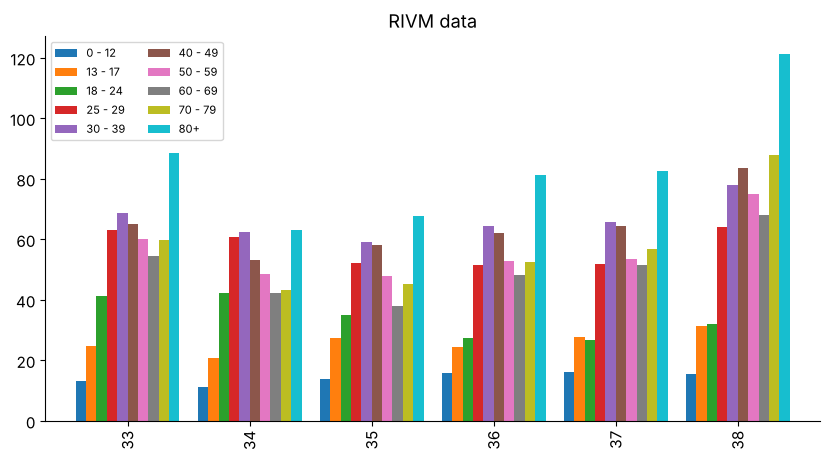

In [5]:
df.T.plot(kind="bar", figsize=(10, 5), width=0.85)
plt.title("RIVM data")
plt.legend(ncol=2, fontsize=8)
plt.show()

**Wat gaat er mis (volgens SWD)?**
- **60 staven en 10 kleuren**: het oog weet niet waar het moet kijken.
- **Legenda**: de lezer moet heen en weer kijken tussen kleur en legenda (onnodige *cognitive load*).
- **Staven bij een tijdreeks**: een trend zie je slecht in losse staven.
- **De titel zegt niets**: "RIVM data" vertelt niet wat de conclusie is.

## Stap 4 – Les 2: kies de juiste visual → lijngrafiek

**Plan:** de x-as is *tijd* (weken). SWD adviseert voor tijdreeksen een **lijngrafiek**, omdat een lijn de richting (stijgen/dalen) direct laat zien. Eerst een kale versie, nog zonder ontwerpkeuzes:

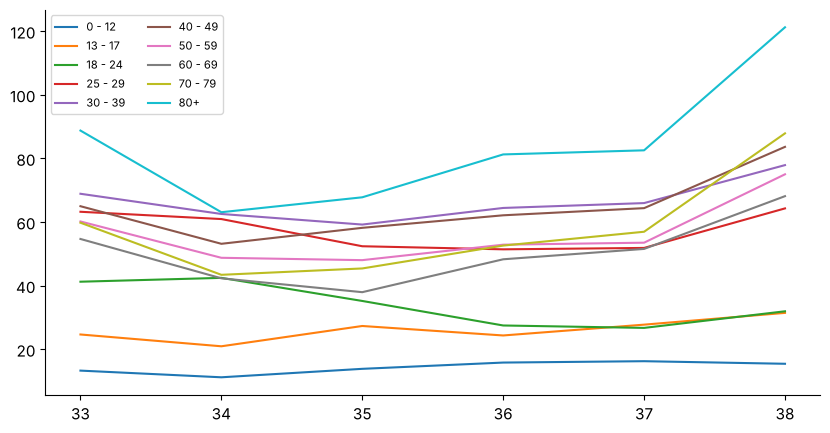

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for groep, rij in df.iterrows():
    ax.plot(weken, rij.values, label=groep)
ax.legend(ncol=2, fontsize=8)
plt.show()

**Interpretatie:** de trend is nu beter te zien, maar het blijft een "spaghettigrafiek" met 10 kleuren. De volgende stappen lossen dat op.

## Stap 5 – Les 3 t/m 6: de uiteindelijke visual

**Plan:** we passen alle overige lessen tegelijk toe. Per keuze staat in de code als commentaar welke les erbij hoort:

- **Les 3, clutter weg:** geen kader, geen rasterlijnen, geen legenda, grijze assen.
- **Les 4, aandacht sturen:** alle groepen grijs, alleen 70–79 en 80+ rood en dikker. Week 38 krijgt een lichte achtergrond.
- **Les 5, ontwerp:** labels direct aan het eind van de lijn, titel links uitgelijnd (we lezen van linksboven naar rechtsonder).
- **Les 6, verhaal:** de titel is de conclusie (*action title*), de ondertitel geeft de onderbouwing.

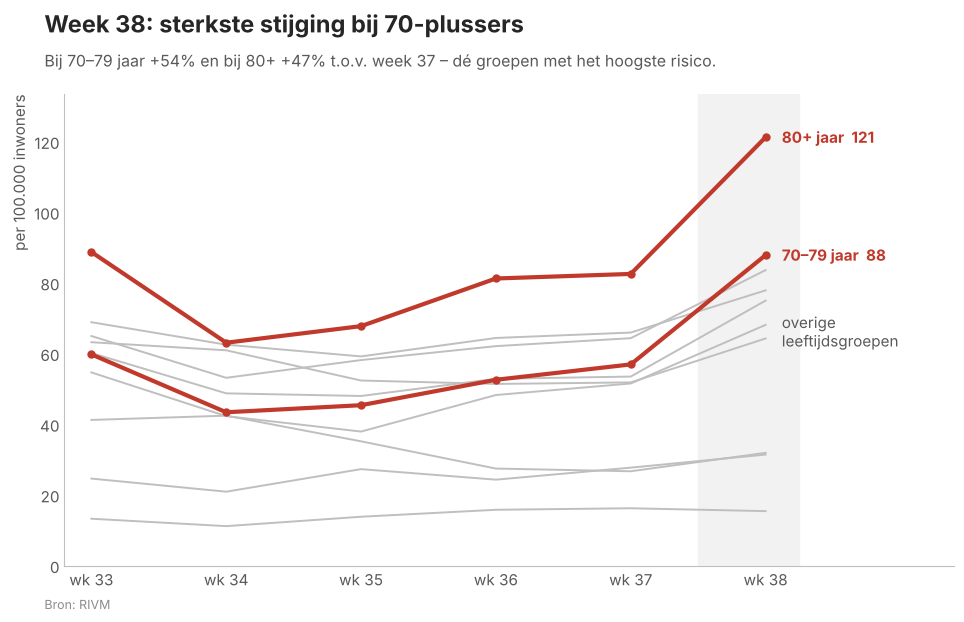

In [7]:
stijging_pct = (df[38] - df[37]) / df[37] * 100

fig, ax = plt.subplots(figsize=(10, 6.2))

for groep, rij in df.iterrows():
    is_hl = groep in HIGHLIGHT
    ax.plot(weken, rij.values,
            color=ACCENT if is_hl else GRIJS,      # les 4: kleur alleen voor het verhaal
            linewidth=3 if is_hl else 1.4,          # les 4: dikte = belangrijkheid
            zorder=3 if is_hl else 2,               # rode lijnen bovenop
            marker="o" if is_hl else None, markersize=5)

    if is_hl:                                       # les 5: directe labels i.p.v. legenda
        ax.text(weken[-1] + 0.12, rij.iloc[-1],
                f"{groep.replace(' - ', '–')} jaar  {rij.iloc[-1]:.0f}",
                color=ACCENT, va="center", fontweight="bold")

# één label voor alle grijze lijnen samen
ax.text(weken[-1] + 0.12, df.loc[~df.index.isin(HIGHLIGHT), 38].median(),
        "overige\nleeftijdsgroepen", color=DONKERGRIJS, va="center")

ax.axvspan(37.5, 38.25, color="#F2F2F2", zorder=0)  # les 4: focus op de laatste week

# les 3: clutter weg
ax.set_xticks(weken, [f"wk {w}" for w in weken])
ax.set_xlim(weken[0] - 0.2, weken[-1] + 1.4)
ax.set_ylim(0, df.values.max() * 1.1)
ax.set_ylabel(EENHEID, color=DONKERGRIJS, loc="top")
for kant in ("left", "bottom"):
    ax.spines[kant].set_color(GRIJS)
ax.tick_params(colors=DONKERGRIJS, length=0)

# les 6: action title + onderbouwing, links uitgelijnd
fig.text(0.06, 0.95, "Week 38: sterkste stijging bij 70-plussers",
         fontsize=17, fontweight="bold", color="#262626")
fig.text(0.06, 0.895,
         f"Bij 70–79 jaar +{stijging_pct['70 - 79']:.0f}% en bij 80+ +{stijging_pct['80+']:.0f}% "
         "t.o.v. week 37 – dé groepen met het hoogste risico.",
         fontsize=11.5, color=DONKERGRIJS)
fig.text(0.06, 0.02, "Bron: RIVM", fontsize=9, color="#8C8C8C")

fig.subplots_adjust(top=0.85, left=0.08, right=0.97, bottom=0.09)
fig.savefig("rivm_lijngrafiek.png", dpi=200)
plt.show()

**Interpretatie:** in een paar seconden zie je nu:
1. **wat** er gebeurt: in week 38 gaat bijna alles omhoog,
2. **waar** het zit: 70-plussers stijgen het hardst,
3. **hoe erg** het is: 80+ zit op 121, ver boven de rest.

De grijze lijnen blijven zichtbaar als context ("vergeleken met wat?"), maar leiden niet af.

## Stap 6 – Ondersteunende visual: procentuele stijging

**Plan:** de lijngrafiek toont *niveaus*. Wil je de *stijging per groep* direct vergelijken, dan werkt een **gesorteerde horizontale staafgrafiek** het best. SWD:
- **horizontaal**: lange labels (leeftijdsgroepen) zijn makkelijk te lezen,
- **gesorteerd**: de lezer ziet meteen wie bovenaan staat,
- **waarden bij de staaf**: dan is de x-as overbodig (minder clutter),
- **zelfde kleurlogica**: rood = 70-plussers, zodat beide grafieken één verhaal vertellen.

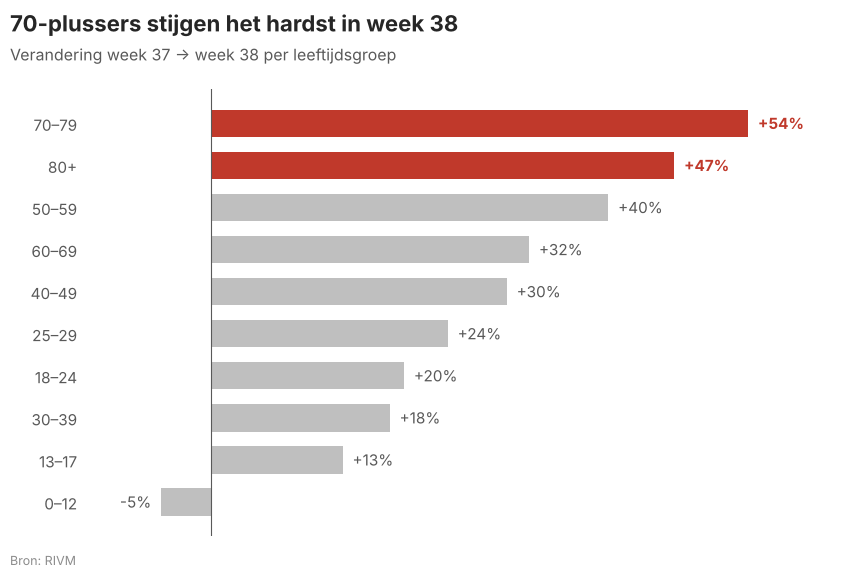

In [8]:
s = stijging_pct.sort_values()
kleuren = [ACCENT if g in HIGHLIGHT else GRIJS for g in s.index]

fig2, ax2 = plt.subplots(figsize=(9, 5.8))
ax2.barh([g.replace(" - ", "–") for g in s.index], s.values, color=kleuren, height=0.65)
ax2.axvline(0, color=DONKERGRIJS, linewidth=0.8)

for i, v in enumerate(s.values):                     # waarde direct bij de staaf
    hl = s.index[i] in HIGHLIGHT
    ax2.text(v + (1 if v >= 0 else -1), i, f"{v:+.0f}%",
             va="center", ha="left" if v >= 0 else "right",
             color=ACCENT if hl else DONKERGRIJS,
             fontweight="bold" if hl else "normal")

ax2.set_xticks([])                                   # x-as overbodig
for kant in ("bottom", "left"):
    ax2.spines[kant].set_visible(False)
ax2.tick_params(colors=DONKERGRIJS, length=0)
ax2.set_xlim(s.min() - 8, s.max() + 10)

fig2.text(0.04, 0.94, "70-plussers stijgen het hardst in week 38",
          fontsize=16, fontweight="bold", color="#262626")
fig2.text(0.04, 0.89, "Verandering week 37 → week 38 per leeftijdsgroep",
          fontsize=11.5, color=DONKERGRIJS)
fig2.text(0.04, 0.02, "Bron: RIVM", fontsize=9, color="#8C8C8C")
fig2.subplots_adjust(top=0.84, left=0.12, right=0.97, bottom=0.07)
fig2.savefig("rivm_stijging_week38.png", dpi=200)
plt.show()

**Interpretatie:** 70–79 jaar (+54%) en 80+ (+47%) staan bovenaan. Daarna volgen 50–59 (+40%) en 60–69 (+32%). Alleen 0–12 jaar daalt (−5%).

## Conclusie

| Voor (standaard) | Na (SWD) | Les |
|---|---|---|
| Geclusterde staven | Lijngrafiek | 2: juiste visual voor tijdreeks |
| 10 kleuren + legenda | Grijs + 1 accentkleur, directe labels | 3 & 4: clutter weg, aandacht sturen |
| Titel "RIVM data" | Titel = conclusie | 6: vertel een verhaal |
| Lezer zoekt zelf | Lezer ziet het verhaal in seconden | 1: context eerst |

**Kernboodschap:** in week 38 stijgen de cijfers in bijna alle leeftijdsgroepen, het sterkst bij 70-plussers (+54% en +47%). Omdat dit de kwetsbaarste groepen zijn, verdient deze ontwikkeling extra aandacht.